In [1]:
from sympy import plot_implicit, symbols, Eq

In [2]:
x, y = symbols('x y')
f = y - x**2
wall = 27*x**2 - 1/4 * (1+2*y)**3

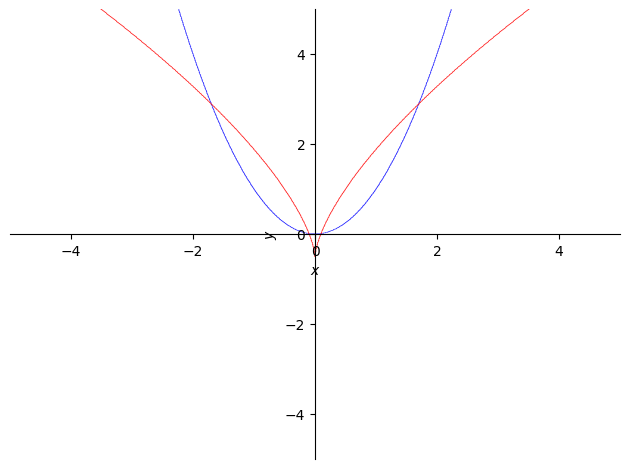

In [3]:
p1 = plot_implicit(Eq(f, 0), (x, -5, 5), (y, -5, 5), show=False)
p2 = plot_implicit(Eq(wall, 0), (x, -5, 5), (y, -5, 5), show=False)

# Optionally, set colors for distinction
p1[0].line_color = 'blue'
p2[0].line_color = 'red'

p1.append(p2[0])
p1.show()

In [4]:
import phcpy
from phcpy.dimension import get_core_count
from phcpy.solver import solve
from phcpy.solutions import filter_real

H = [
    'x - 1 - x*l;',
    'y - 10 + 0.5*l;',
    '27*x^2 - 0.25*(1 + 2*y)^3;'
]
sols = solve(H)
realsols = filter_real(sols, tol=1.0e-8, oper='select')
for (idx, sol) in enumerate(realsols):
    print('Solution', idx+1, ':')
    print(sol)

PHCv2.4.90 released 2024-03-20 works!
Solution 1 :
t :  1.00000000000000E+00   0.00000000000000E+00
m : 1
the solution for t :
 x : -5.17089143180654E-02   0.00000000000000E+00
 l :  2.03390252568237E+01   0.00000000000000E+00
 y : -1.69512628411859E-01  -9.81818693059545E-91
== err :  5.495E-17 = rco :  1.915E-03 = res :  1.735E-18 =
Solution 2 :
t :  1.00000000000000E+00   0.00000000000000E+00
m : 1
the solution for t :
 x : -8.53107641449643E+00  -2.85746847820569E-101
 l :  1.11721850226318E+00  -5.71493695641137E-101
 y :  9.44139074886841E+00   2.85746847820569E-101
== err :  8.107E-16 = rco :  1.310E-03 = res :  5.712E-14 =
Solution 3 :
t :  1.00000000000000E+00   0.00000000000000E+00
m : 1
the solution for t :
 x :  8.68109329667665E+00   0.00000000000000E+00
 l :  8.84807135941872E-01   8.46021120509121E-100
 y :  9.55759643202906E+00   0.00000000000000E+00
== err :  1.585E-15 = rco :  1.267E-03 = res :  1.804E-16 =


In [5]:
from sympy import symbols, Matrix, groebner, factor

def ed_discriminant_minimal(F, xs, us, lam):
    """
    ED discriminant (hypersurface case) via elimination:
      - equations: F(x)=0,  u = x - lam * grad F
      - degeneracy: det Jacobian wrt (x, lam) = 0
      - eliminate (x, lam) -> polynomials in u only

    Args
    ----
    F   : SymPy Expr in xs
    xs  : tuple/list of SymPy symbols (x1,...,xn)
    us  : tuple/list of SymPy symbols (u1,...,un)
    lam : SymPy symbol for lambda

    Returns
    -------
    list[Expr] : generators in Q[us] that vanish on the ED discriminant.
    """
    n = len(xs)
    # Lagrange equations: F=0 and u_i - (x_i - lam*F_{x_i}) = 0
    eqs = [F] + [us[i] - (xs[i] - lam*F.diff(xs[i])) for i in range(n)]

    # Jacobian of these n+1 equations wrt (x, lam)  -> (n+1)x(n+1)
    vars_all = list(xs) + [lam]
    J = Matrix([[eq.diff(v) for v in vars_all] for eq in eqs])
    detJ = J.det()
    print("Determinant of Jacobian:", detJ)

    gens = eqs + [detJ]

    # Eliminate (xs, lam).  For lex order, put elimination vars FIRST.
    G = groebner(gens, *vars_all, *us, order='lex')
    print("Groebner basis computed.", G)

    # Extract the polynomials that involve only the u's
    U = set(us)
    discrim_in_u = []
    for g in G.polys:
        expr = g.as_expr()
        if expr.free_symbols <= U:
            discrim_in_u.append(factor(expr))

    # If nothing shows up (rare), try the basis of the elimination ideal directly:
    if not discrim_in_u:
        # Reduce gens modulo G and filter again
        discrim_in_u = [factor(g.as_expr()) for g in G.eliminate(*vars_all)]

    return discrim_in_u


In [6]:
# Variables
x, z, lam = symbols('x z lambda')
u1, u2 = symbols('u1 u2')

F = z - x**2
disc = ed_discriminant_minimal(F, (x, z), (u1, u2), lam)
disc


Determinant of Jacobian: 2*lambda + 4*x**2 + 1
Groebner basis computed. GroebnerBasis([-2*u2 + 6*x**2 + 1, 9*u1*x + 4*u2**2 - 4*u2 + 1, 3*u1 + 4*u2*x - 2*x, -2*u2 + 6*z + 1, 6*lambda + 4*u2 + 1, 27*u1**2 - 16*u2**3 + 24*u2**2 - 12*u2 + 2], x, z, lambda, u1, u2, domain='ZZ', order='lex')


[27*u1**2 - 16*u2**3 + 24*u2**2 - 12*u2 + 2]